[2026-05-22 12:59:57 | +0.0s] ================================================================================
[2026-05-22 12:59:57 | +0.0s] ランキング + 元時系列2列subplot開始
[2026-05-22 12:59:58 | +0.4s] ================================================================================
[2026-05-22 12:59:58 | +0.4s] 使用 変化点CSV: D:\musashino-university\finance\change_point_output_advanced\advanced_change_point_pairs_ALL_ADVANCED_METHODS_20260519_182858.csv
[2026-05-22 12:59:58 | +0.5s] 元時系列ディレクトリ: D:\musashino-university\finance\coingecko_by_coin
[2026-05-22 13:00:31 | +33.9s] 変化点CSV 行数: 519,754
[2026-05-22 13:00:31 | +34.0s] 変化点CSV 列数: 11
[2026-05-22 13:00:31 | +34.0s] ================================================================================
[2026-05-22 13:00:31 | +34.1s] 推定列
[2026-05-22 13:00:32 | +34.2s] coin_col     : symbol
[2026-05-22 13:00:32 | +34.3s] strength_col : cp_strength
[2026-05-22 13:00:32 | +34.3s] datetime_col : cp_datetime
[2026-05-22 13:00:32 | +34.5s] method_col   : meth

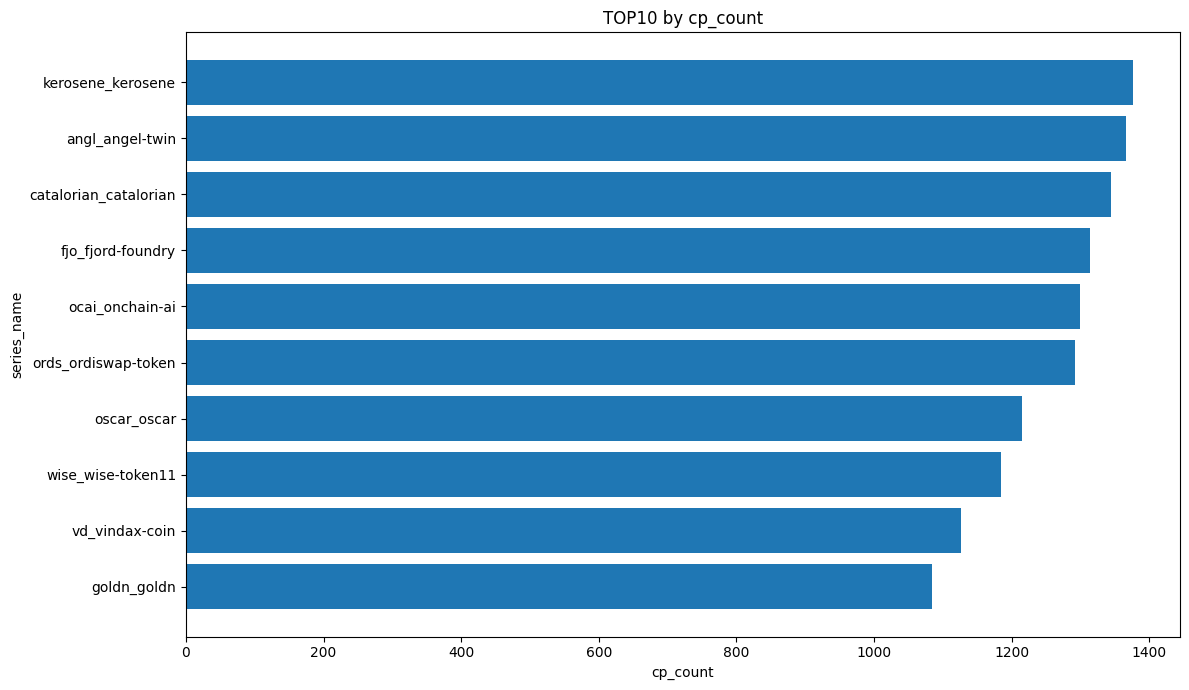

[2026-05-22 13:00:47 | +49.7s] 保存: D:\musashino-university\finance\change_point_output_advanced\ranking_output\top10_cp_strength_sum_20260522_125957.png


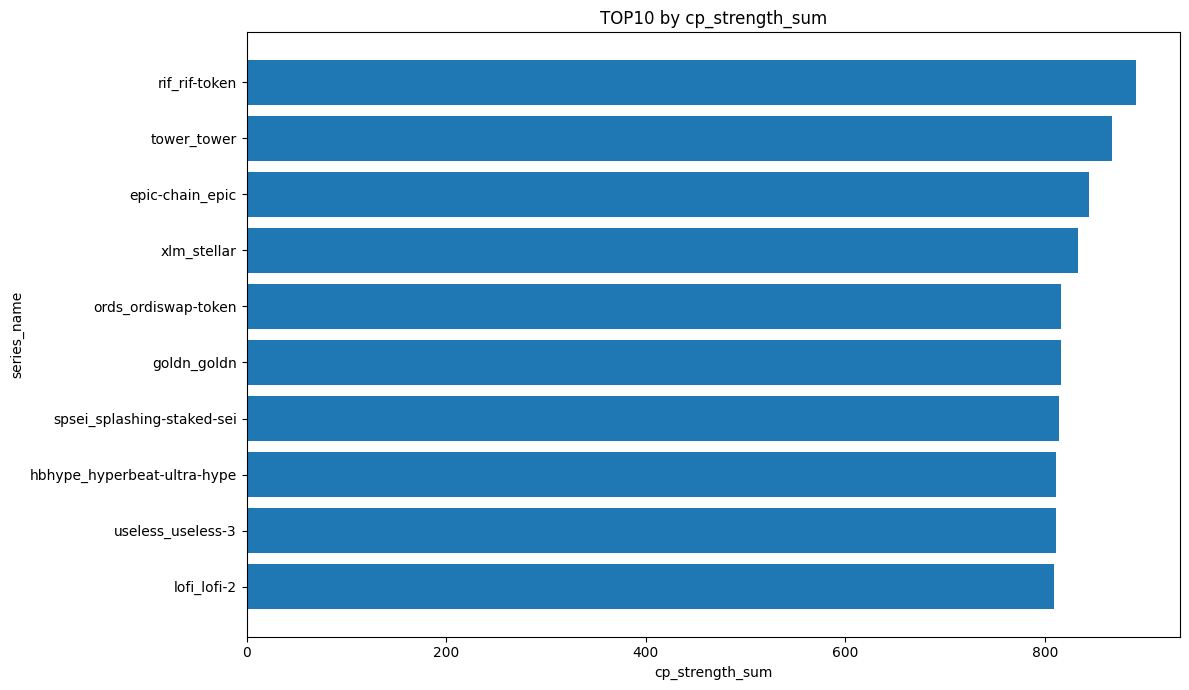

[2026-05-22 13:00:48 | +50.2s] ================================================================================
[2026-05-22 13:00:48 | +50.3s] CoinGecko 元CSV検索
[2026-05-22 13:00:48 | +50.4s] 元時系列CSV数: 1,099
[2026-05-22 13:00:48 | +50.6s] ================================================================================
[2026-05-22 13:00:48 | +50.9s] 元時系列2列subplot開始: cp_count
[2026-05-22 13:01:07 | +69.9s] 保存: D:\musashino-university\finance\change_point_output_advanced\ranking_output\top10_time_series_plots\cp_count_top10_2col_subplot_20260522_125957.png


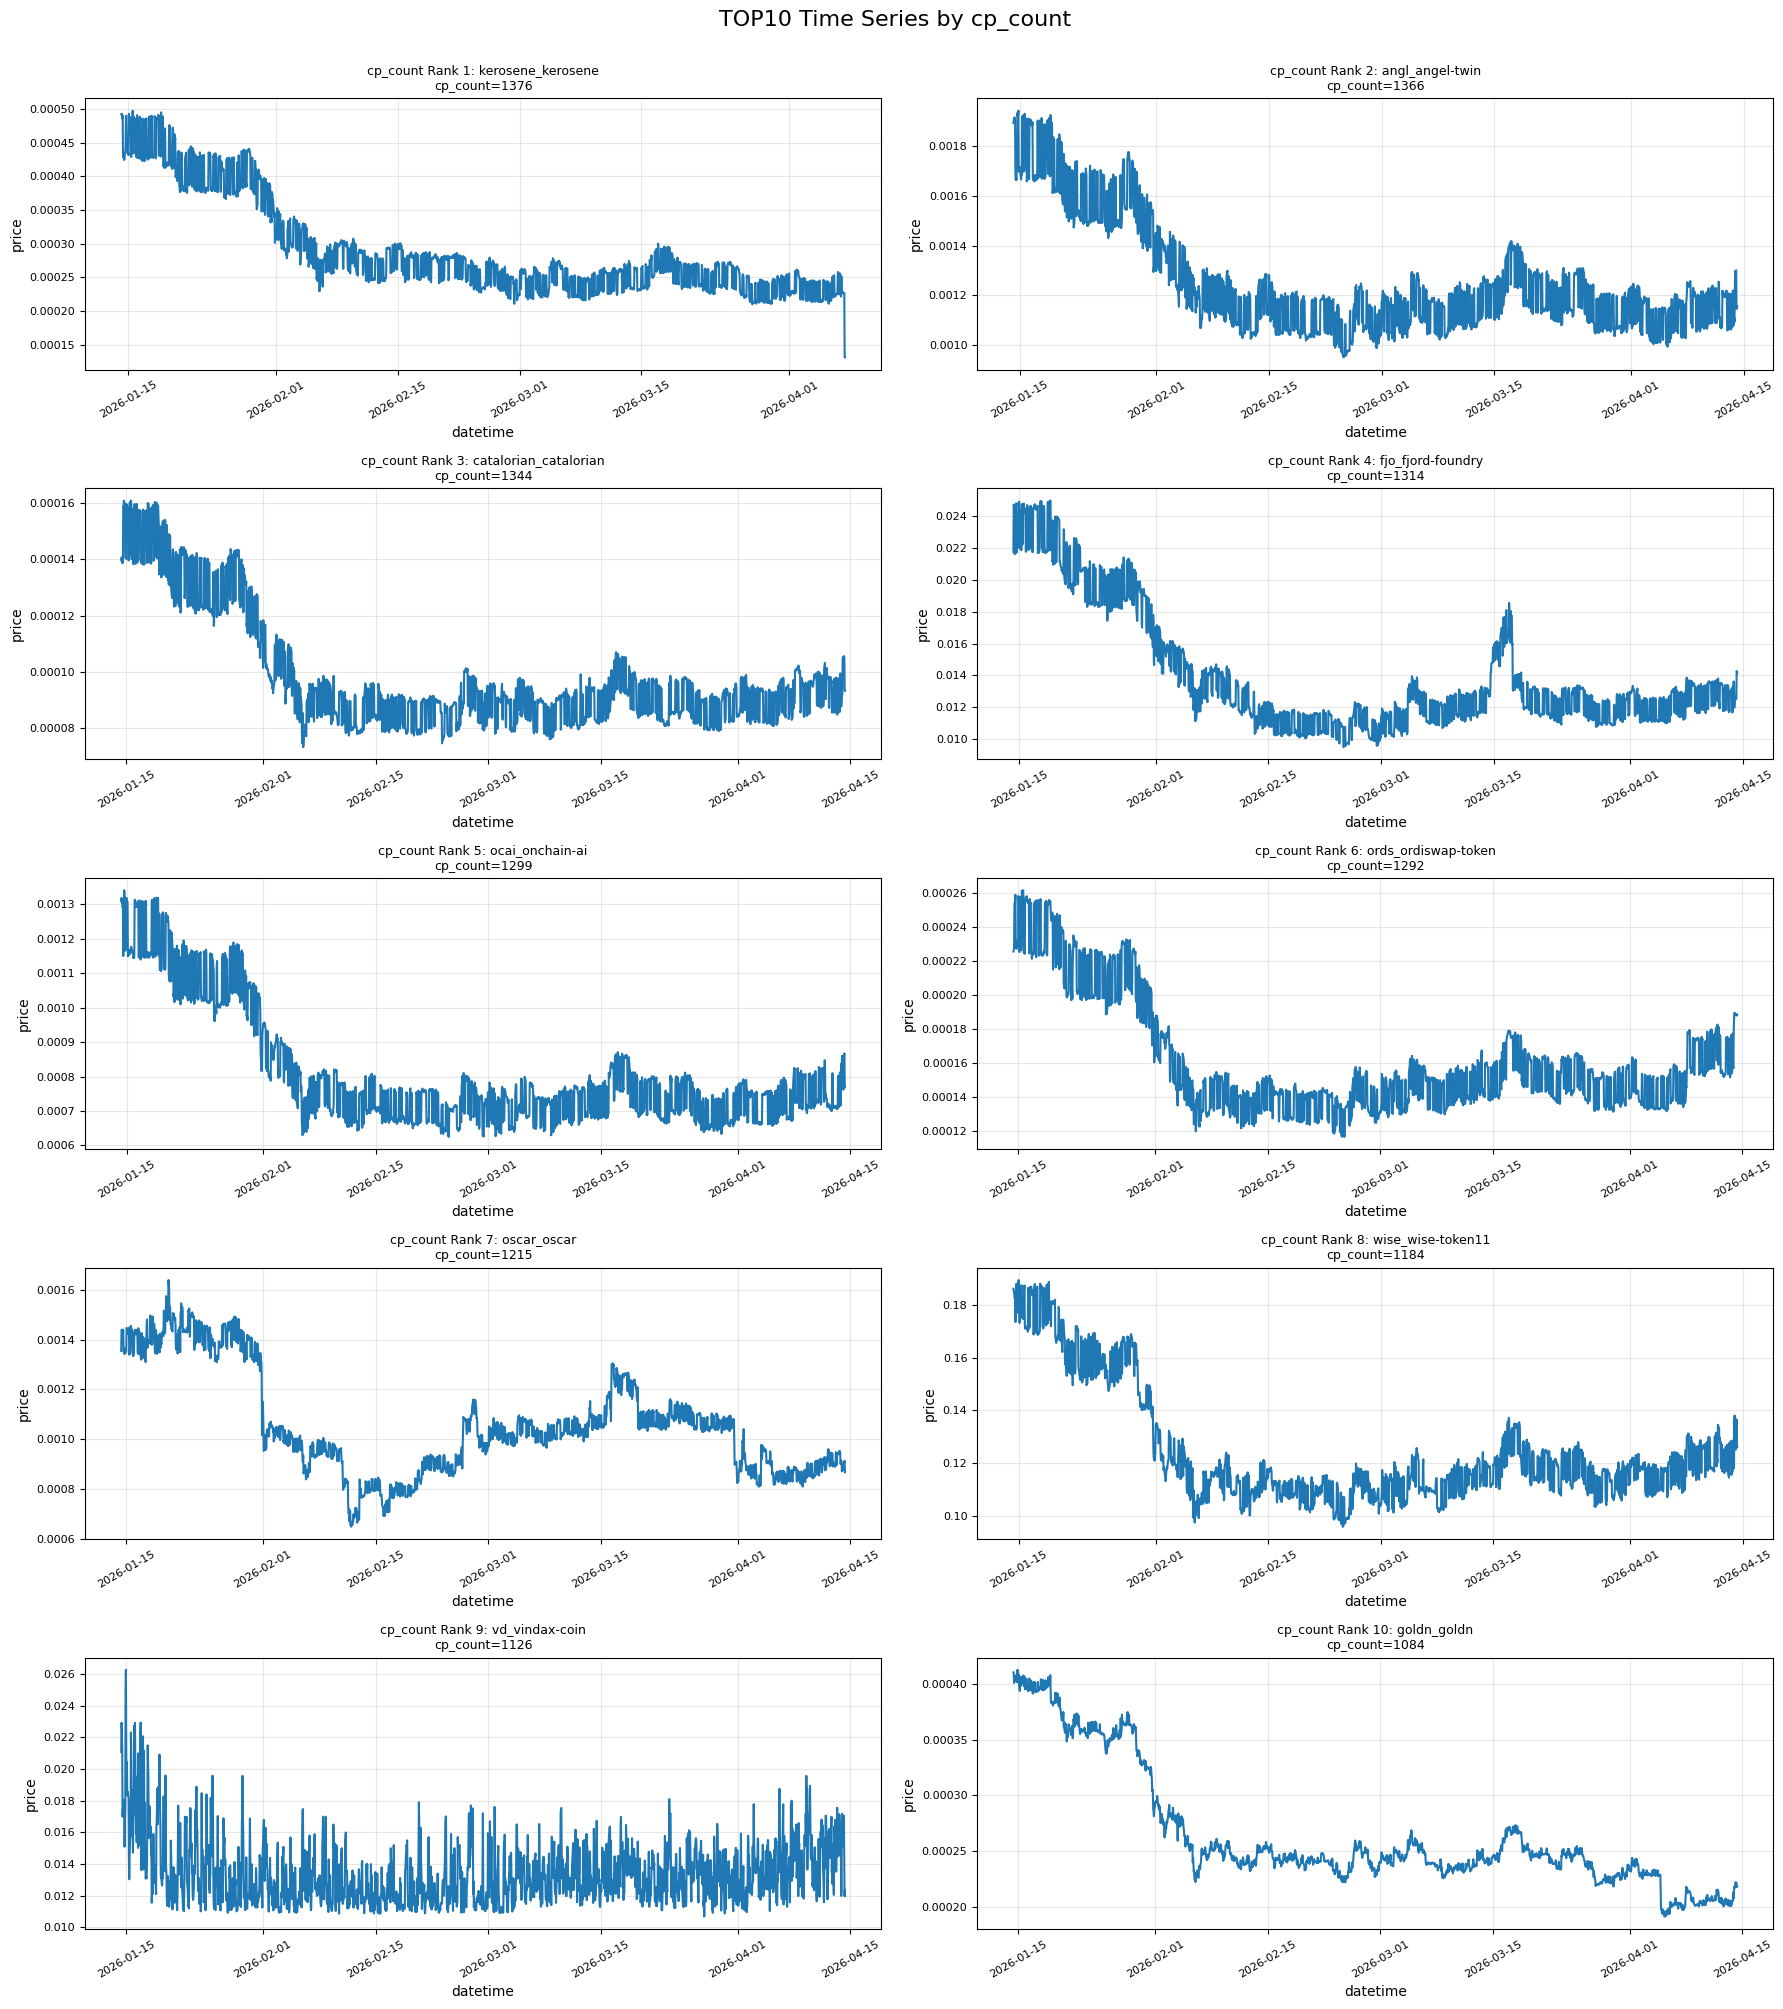

[2026-05-22 13:01:12 | +74.5s] 元時系列2列subplot完了: saved=10, skipped=0
[2026-05-22 13:01:12 | +74.7s] ================================================================================
[2026-05-22 13:01:12 | +74.7s] 元時系列2列subplot開始: cp_strength_sum
[2026-05-22 13:01:21 | +83.3s] 保存: D:\musashino-university\finance\change_point_output_advanced\ranking_output\top10_time_series_plots\cp_strength_sum_top10_2col_subplot_20260522_125957.png


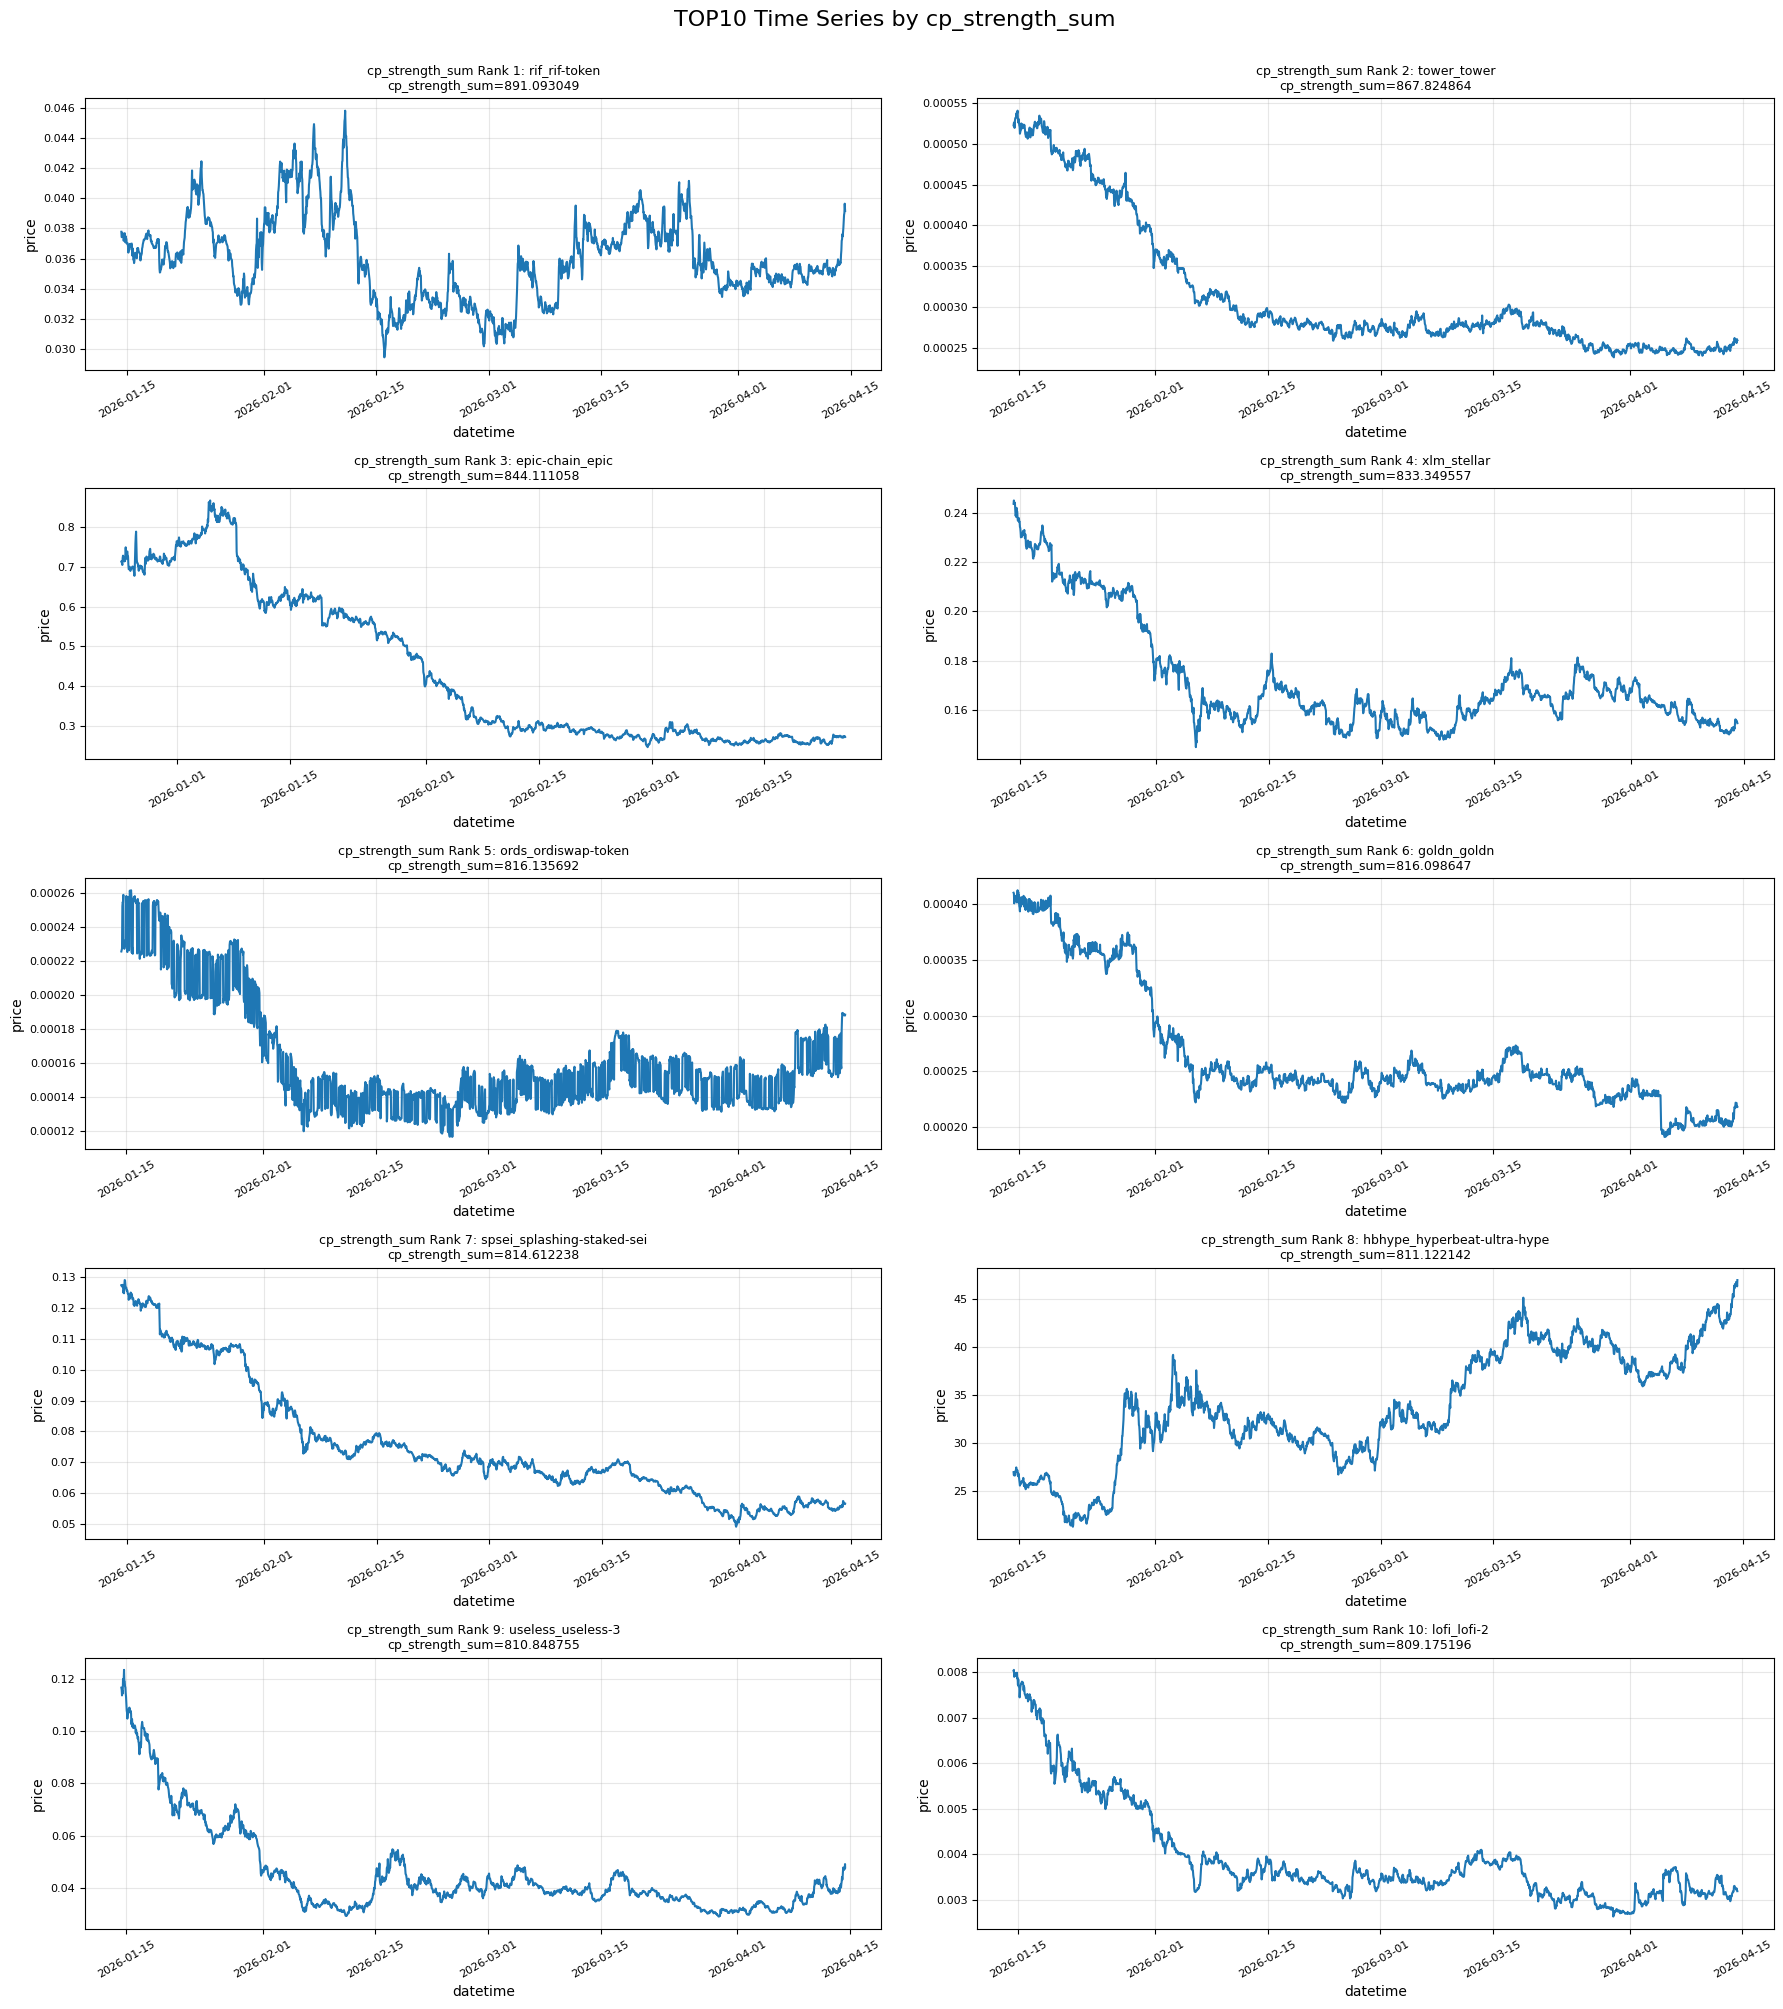

[2026-05-22 13:01:24 | +86.9s] 元時系列2列subplot完了: saved=10, skipped=0
[2026-05-22 13:01:24 | +86.9s] ================================================================================
[2026-05-22 13:01:24 | +87.0s] 完了
[2026-05-22 13:01:24 | +87.0s] ランキング出力: D:\musashino-university\finance\change_point_output_advanced\ranking_output
[2026-05-22 13:01:24 | +87.0s] 元時系列2列プロット出力: D:\musashino-university\finance\change_point_output_advanced\ranking_output\top10_time_series_plots
[2026-05-22 13:01:24 | +87.1s] ログ: D:\musashino-university\finance\change_point_output_advanced\ranking_output\top10_ranking_with_2col_timeseries_log_20260522_125957.txt
[2026-05-22 13:01:24 | +87.1s] ================================================================================


In [6]:
# =============================================================================
# cp_count / cp_strength_sum TOP10ランキング
# + ランキング棒グラフ
# + 元時系列本体を2列subplotでプロット 完全版
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import time
import re

# =============================================================================
# パラメータ
# =============================================================================

CHANGE_POINT_DIR = Path(r"D:\musashino-university\finance\change_point_output_advanced")

COINGECKO_DIR = Path(r"D:\musashino-university\finance\coingecko_by_coin")

PAIR_FILE_PATTERN = "advanced_change_point_pairs_ALL_ADVANCED_METHODS_*.csv"

OUTPUT_DIR = CHANGE_POINT_DIR / "ranking_output"
TIME_SERIES_PLOT_DIR = OUTPUT_DIR / "top10_time_series_plots"

TOP_N = 10

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

ENCODING_OUT = "utf-8-sig"

SHOW_PLOTS = True
SAVE_PLOTS = True
PLOT_DPI = 200

USE_LOG_Y = False
NORMALIZE_PRICE = False

N_SUBPLOT_COLS = 2

# =============================================================================
# 出力ディレクトリ
# =============================================================================

OUTPUT_DIR.mkdir(exist_ok=True)
TIME_SERIES_PLOT_DIR.mkdir(exist_ok=True)

START_TIME = time.time()
LOG_FILE = OUTPUT_DIR / f"top10_ranking_with_2col_timeseries_log_{RUN_ID}.txt"

# =============================================================================
# ログ
# =============================================================================

def log(msg=""):
    elapsed = time.time() - START_TIME
    line = (
        f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} "
        f"| +{elapsed:.1f}s] {msg}"
    )
    print(line)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(line + "\n")


# =============================================================================
# 補助関数
# =============================================================================

def find_column(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def safe_name(s):
    s = str(s)
    s = re.sub(r'[\\/:*?"<>|]', "_", s)
    s = s.replace(" ", "_")
    return s[:120]


def normalize_key(s):
    s = str(s).lower()
    s = Path(s).stem
    s = s.replace(".csv", "")
    s = re.sub(r"[^a-z0-9]+", "", s)
    return s


def build_file_index(csv_files):
    index = {}
    for p in csv_files:
        for key in {normalize_key(p.name), normalize_key(p.stem)}:
            if key and key not in index:
                index[key] = p
    return index


def find_timeseries_file(series_name, csv_files, file_index):
    s = str(series_name)

    candidates = [s]

    p = Path(s)
    if p.suffix.lower() == ".csv":
        candidates.append(p.name)
        candidates.append(p.stem)
    else:
        candidates.append(s + ".csv")

    for c in candidates:
        key = normalize_key(c)
        if key in file_index:
            return file_index[key]

    key = normalize_key(s)

    for p in csv_files:
        pk = normalize_key(p.name)

        if key and key in pk:
            return p

        if pk and pk in key:
            return p

    return None


def load_timeseries_csv(csv_path):
    df_ts = pd.read_csv(csv_path)

    datetime_col = find_column(
        df_ts,
        [
            "timestamp",
            "datetime",
            "date",
            "time",
            "Date",
            "Datetime",
            "Timestamp",
            "snapped_at",
        ],
    )

    price_col = find_column(
        df_ts,
        [
            "price",
            "Price",
            "close",
            "Close",
            "market_price",
            "current_price",
            "usd",
            "value",
        ],
    )

    if datetime_col is None:
        object_cols = df_ts.select_dtypes(include=["object"]).columns.tolist()
        for c in object_cols:
            test = pd.to_datetime(df_ts[c], errors="coerce")
            if test.notna().sum() > len(df_ts) * 0.5:
                datetime_col = c
                break

    if price_col is None:
        numeric_cols = df_ts.select_dtypes(include=[np.number]).columns.tolist()
        if len(numeric_cols) > 0:
            price_col = numeric_cols[0]

    if datetime_col is None:
        raise ValueError(f"日時列が見つかりません: {csv_path.name}")

    if price_col is None:
        raise ValueError(f"価格列が見つかりません: {csv_path.name}")

    df_ts[datetime_col] = pd.to_datetime(df_ts[datetime_col], errors="coerce")
    df_ts[price_col] = pd.to_numeric(df_ts[price_col], errors="coerce")

    df_ts = df_ts[[datetime_col, price_col]].dropna()
    df_ts = df_ts.sort_values(datetime_col)

    return df_ts, datetime_col, price_col


def plot_timeseries_for_ranking_2cols(ranking_df, value_col, label_name):
    log("=" * 80)
    log(f"元時系列2列subplot開始: {label_name}")

    n = len(ranking_df)
    ncols = N_SUBPLOT_COLS
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(18, 4 * nrows),
        squeeze=False,
    )

    axes = axes.reshape(-1)

    saved = 0
    skipped = 0

    for idx, (_, row) in enumerate(ranking_df.iterrows()):
        ax = axes[idx]

        rank = int(row["rank"])
        series_name = row["series_name"]

        ts_file = find_timeseries_file(
            series_name,
            coingecko_csv_files,
            coingecko_file_index,
        )

        if ts_file is None:
            ax.set_title(f"Rank {rank}: NOT FOUND\n{series_name}", fontsize=9)
            ax.axis("off")
            log(f"[skip] 元CSVが見つかりません: {series_name}")
            skipped += 1
            continue

        try:
            df_ts, dt_col, price_col = load_timeseries_csv(ts_file)

            if len(df_ts) == 0:
                ax.set_title(f"Rank {rank}: EMPTY\n{series_name}", fontsize=9)
                ax.axis("off")
                log(f"[skip] 有効データなし: {series_name}")
                skipped += 1
                continue

            y = df_ts[price_col].copy()
            ylabel = price_col

            if NORMALIZE_PRICE:
                first_valid = y.dropna().iloc[0]
                if first_valid != 0:
                    y = y / first_valid
                    ylabel = f"{price_col} normalized"

            ax.plot(df_ts[dt_col], y)

            ax.set_title(
                f"{label_name} Rank {rank}: {series_name}\n"
                f"{value_col}={row[value_col]}",
                fontsize=9,
            )

            ax.set_xlabel("datetime")
            ax.set_ylabel(ylabel)

            if USE_LOG_Y:
                ax.set_yscale("log")

            ax.grid(True, alpha=0.3)
            ax.tick_params(axis="x", labelrotation=30, labelsize=8)
            ax.tick_params(axis="y", labelsize=8)

            saved += 1

        except Exception as e:
            ax.set_title(f"Rank {rank}: ERROR\n{series_name}\n{e}", fontsize=8)
            ax.axis("off")
            log(f"[error] {series_name}: {e}")
            skipped += 1

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"TOP{TOP_N} Time Series by {label_name}",
        fontsize=16,
        y=1.002,
    )

    plt.tight_layout()

    out_png = TIME_SERIES_PLOT_DIR / f"{label_name}_top{TOP_N}_2col_subplot_{RUN_ID}.png"

    if SAVE_PLOTS:
        plt.savefig(out_png, dpi=PLOT_DPI, bbox_inches="tight")
        log(f"保存: {out_png}")

    if SHOW_PLOTS:
        plt.show()

    plt.close()

    log(f"元時系列2列subplot完了: saved={saved}, skipped={skipped}")


# =============================================================================
# 開始
# =============================================================================

log("=" * 80)
log("ランキング + 元時系列2列subplot開始")
log("=" * 80)

# =============================================================================
# 変化点CSV読み込み
# =============================================================================

pair_files = sorted(CHANGE_POINT_DIR.glob(PAIR_FILE_PATTERN))

if len(pair_files) == 0:
    raise FileNotFoundError(
        f"対象CSVが見つかりません: {CHANGE_POINT_DIR / PAIR_FILE_PATTERN}"
    )

pair_csv = max(pair_files, key=lambda p: p.stat().st_mtime)

log(f"使用 変化点CSV: {pair_csv}")
log(f"元時系列ディレクトリ: {COINGECKO_DIR}")

df = pd.read_csv(pair_csv)

log(f"変化点CSV 行数: {len(df):,}")
log(f"変化点CSV 列数: {len(df.columns)}")

# =============================================================================
# 列推定
# =============================================================================

coin_col = find_column(
    df,
    [
        "coin",
        "symbol",
        "ticker",
        "file",
        "filename",
        "name",
        "series",
    ],
)

strength_col = find_column(
    df,
    [
        "cp_strength",
        "strength",
        "score",
        "change_strength",
        "cp_score",
    ],
)

datetime_col = find_column(
    df,
    [
        "cp_datetime",
        "datetime",
        "timestamp",
        "date",
        "time",
    ],
)

method_col = find_column(
    df,
    [
        "method",
        "algo",
        "algorithm",
        "model",
    ],
)

log("=" * 80)
log("推定列")
log(f"coin_col     : {coin_col}")
log(f"strength_col : {strength_col}")
log(f"datetime_col : {datetime_col}")
log(f"method_col   : {method_col}")

if coin_col is None:
    raise ValueError("銘柄名・ファイル名に相当する列が見つかりません。")

if strength_col is None:
    log("cp_strength列が無いため 1.0 で補完")
    df["dummy_cp_strength"] = 1.0
    strength_col = "dummy_cp_strength"

if method_col is None:
    df["dummy_method"] = "unknown_method"
    method_col = "dummy_method"

if datetime_col is not None:
    df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
    df["cp_date"] = df[datetime_col].dt.date
else:
    df["cp_date"] = np.nan

df[strength_col] = pd.to_numeric(df[strength_col], errors="coerce").fillna(0)

# =============================================================================
# 集計
# =============================================================================

summary_df = (
    df.groupby(coin_col)
    .agg(
        cp_count=(coin_col, "size"),
        cp_strength_sum=(strength_col, "sum"),
        cp_strength_mean=(strength_col, "mean"),
        cp_strength_max=(strength_col, "max"),
        methods_detected=(method_col, "nunique"),
        unique_detection_days=("cp_date", "nunique"),
    )
    .reset_index()
)

summary_df = summary_df.rename(columns={coin_col: "series_name"})

summary_df["cp_strength_sum"] = summary_df["cp_strength_sum"].round(6)
summary_df["cp_strength_mean"] = summary_df["cp_strength_mean"].round(6)
summary_df["cp_strength_max"] = summary_df["cp_strength_max"].round(6)

# =============================================================================
# TOP10作成
# =============================================================================

top_cp_count = (
    summary_df
    .sort_values(["cp_count", "cp_strength_sum"], ascending=[False, False])
    .head(TOP_N)
    .reset_index(drop=True)
)

top_cp_count.insert(0, "rank", np.arange(1, len(top_cp_count) + 1))

top_strength_sum = (
    summary_df
    .sort_values(["cp_strength_sum", "cp_count"], ascending=[False, False])
    .head(TOP_N)
    .reset_index(drop=True)
)

top_strength_sum.insert(0, "rank", np.arange(1, len(top_strength_sum) + 1))

# =============================================================================
# 表示
# =============================================================================

log("=" * 80)
log("cp_count TOP10")
print(top_cp_count.to_string(index=False))

log("=" * 80)
log("cp_strength_sum TOP10")
print(top_strength_sum.to_string(index=False))

# =============================================================================
# CSV保存
# =============================================================================

top_cp_count_csv = OUTPUT_DIR / f"top10_cp_count_{RUN_ID}.csv"
top_strength_sum_csv = OUTPUT_DIR / f"top10_cp_strength_sum_{RUN_ID}.csv"
summary_csv = OUTPUT_DIR / f"cp_ranking_summary_{RUN_ID}.csv"

top_cp_count.to_csv(top_cp_count_csv, index=False, encoding=ENCODING_OUT)
top_strength_sum.to_csv(top_strength_sum_csv, index=False, encoding=ENCODING_OUT)
summary_df.to_csv(summary_csv, index=False, encoding=ENCODING_OUT)

log(f"保存: {top_cp_count_csv}")
log(f"保存: {top_strength_sum_csv}")
log(f"保存: {summary_csv}")

# =============================================================================
# ランキング棒グラフ
# =============================================================================

log("=" * 80)
log("ランキング棒グラフ生成")

plt.figure(figsize=(12, 7))
plot_df = top_cp_count.sort_values("cp_count", ascending=True)
plt.barh(plot_df["series_name"].astype(str), plot_df["cp_count"])
plt.xlabel("cp_count")
plt.ylabel("series_name")
plt.title("TOP10 by cp_count")
plt.tight_layout()

cp_count_png = OUTPUT_DIR / f"top10_cp_count_{RUN_ID}.png"
plt.savefig(cp_count_png, dpi=PLOT_DPI)
log(f"保存: {cp_count_png}")

if SHOW_PLOTS:
    plt.show()

plt.close()

plt.figure(figsize=(12, 7))
plot_df = top_strength_sum.sort_values("cp_strength_sum", ascending=True)
plt.barh(plot_df["series_name"].astype(str), plot_df["cp_strength_sum"])
plt.xlabel("cp_strength_sum")
plt.ylabel("series_name")
plt.title("TOP10 by cp_strength_sum")
plt.tight_layout()

strength_png = OUTPUT_DIR / f"top10_cp_strength_sum_{RUN_ID}.png"
plt.savefig(strength_png, dpi=PLOT_DPI)
log(f"保存: {strength_png}")

if SHOW_PLOTS:
    plt.show()

plt.close()

# =============================================================================
# CoinGecko 元CSV検索
# =============================================================================

log("=" * 80)
log("CoinGecko 元CSV検索")

if not COINGECKO_DIR.exists():
    raise FileNotFoundError(f"元時系列ディレクトリが見つかりません: {COINGECKO_DIR}")

coingecko_csv_files = sorted(COINGECKO_DIR.rglob("*.csv"))

log(f"元時系列CSV数: {len(coingecko_csv_files):,}")

if len(coingecko_csv_files) == 0:
    raise FileNotFoundError(f"CSVが見つかりません: {COINGECKO_DIR}")

coingecko_file_index = build_file_index(coingecko_csv_files)

# =============================================================================
# 元時系列本体 2列subplot
# =============================================================================

plot_timeseries_for_ranking_2cols(
    top_cp_count,
    value_col="cp_count",
    label_name="cp_count",
)

plot_timeseries_for_ranking_2cols(
    top_strength_sum,
    value_col="cp_strength_sum",
    label_name="cp_strength_sum",
)

# =============================================================================
# 完了
# =============================================================================

log("=" * 80)
log("完了")
log(f"ランキング出力: {OUTPUT_DIR}")
log(f"元時系列2列プロット出力: {TIME_SERIES_PLOT_DIR}")
log(f"ログ: {LOG_FILE}")
log("=" * 80)